In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, root_mean_squared_error


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/data science practice /student_placement_prediction_dataset_2026.csv')
df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


# **Using Linear Regression for salary & Classification for placement**

### Data cleaning and preprocessing

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  object 
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  object 
 5   college_tier               100000 non-null  object 
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100

In [ ]:
df.apply(lambda col: col.unique())

,0
student_id,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
age,"[24, 21, 22, 20, 19, 23, 18]"
gender,"[Male, Female]"
cgpa,"[7.53, 7.92, 8.6, 6.68, 8.43, 7.44, 7.54, 6.86..."
branch,"[IT, CSE, EEE, Civil, Mechanical, ECE]"
college_tier,"[Tier 2, Tier 1, Tier 3]"
internships_count,"[4, 1, 0, 3, 2, 7, 5, 6, 8]"
projects_count,"[6, 3, 1, 2, 4, 5, 0, 7, 8, 10, 9, 11, 12, 13]"
certifications_count,"[1, 6, 2, 3, 0, 4, 8, 5, 7, 9, 11, 10]"
coding_skill_score,"[99.23856840567274, 80.9661232609562, 49.17718..."


In [ ]:
df.isna().sum()

,0
student_id,0
age,0
gender,0
cgpa,0
branch,0
college_tier,0
internships_count,0
projects_count,0
certifications_count,0
coding_skill_score,0


In [ ]:
df.round(2)

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.24,...,72.65,77.46,2,63.38,52.94,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.97,...,61.70,88.89,1,73.69,60.20,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.18,...,87.40,74.15,0,63.33,43.71,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.36,...,58.40,87.64,1,47.64,56.55,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.02,...,74.49,79.12,1,0.00,67.27,No,8.7,3.4,Placed,12.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,Male,7.97,Mechanical,Tier 2,0,3,5,71.48,...,57.74,75.47,0,54.40,66.45,Yes,8.0,4.3,Placed,14.54
99996,99997,18,Female,7.79,CSE,Tier 1,1,1,2,78.96,...,80.08,77.29,1,33.69,69.03,Yes,4.4,3.1,Not Placed,0.00
99997,99998,20,Female,6.71,IT,Tier 2,2,4,4,66.69,...,70.80,93.12,0,64.99,32.73,Yes,7.6,2.9,Placed,13.45
99998,99999,19,Female,7.21,CSE,Tier 2,2,3,0,67.21,...,68.18,71.31,1,72.48,32.21,No,4.9,2.8,Not Placed,0.00


# **Data Cleaning**

In [ ]:
df['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [ ]:
df['branch'].unique()

array(['IT', 'CSE', 'EEE', 'Civil', 'Mechanical', 'ECE'], dtype=object)

In [ ]:
df['gender'] = df['gender'].str.strip().map({'Male': 0, 'Female': 1})
df['volunteer_experience'] = df['volunteer_experience'].str.strip().map({'No': 0, 'Yes': 1})
df['placement_status'] = df['placement_status'].str.strip().map({'Placed': 1, 'Not Placed': 0})
df['college_tier'] = df['college_tier'].str.strip().map({'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3})
df['branch'] = df['branch'].str.strip().map({'IT' : 1, 'CSE' :2, 'EEE':3, 'Civil':4, 'Mechanical':5, 'ECE':6})


In [ ]:
X = df.drop(['salary_package_lpa'], axis=1)
y = df['salary_package_lpa']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Using Linear Regression to predict salary**

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

print("MAE: ",mean_absolute_error(y_test, y_pred))
print("MSE: ",mean_squared_error(y_test, y_pred))
print("R2 Score: ",r2_score(y_test, y_pred))
print("RMSE: ",root_mean_squared_error(y_test, y_pred))

MAE:  0.746250828226213
MSE:  0.9203732153070139
R2 Score:  0.9796596760791879
RMSE:  0.9593608368632804


In [ ]:
print('Predicted salary packege: ')
print(y_pred)

Predicted salary packege: 
[-0.32898511 12.43551236 13.79092485 ... 12.47638908 13.9082518
  1.21127961]


In [ ]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df)

,Actual,Predicted
75721,0.00,-0.328985
80184,12.29,12.435512
19864,13.18,13.790925
76699,12.50,12.937504
92991,15.13,14.080317
...,...,...
32595,0.00,0.172490
29313,0.00,1.041259
37862,10.81,12.476389
53421,15.12,13.908252


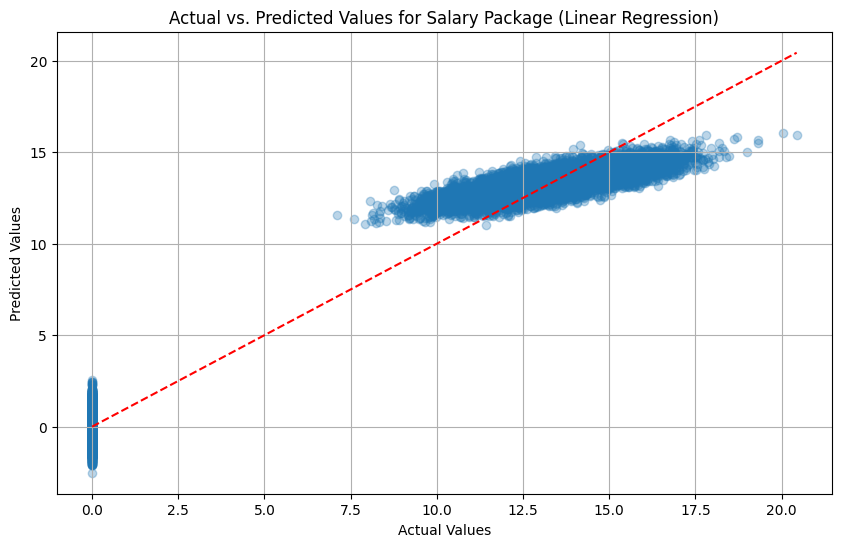

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Salary Package (Linear Regression)')
plt.grid(True)
plt.show()

# **Using Classification, predict placement**

In [ ]:
X2 = df.drop(['placement_status'], axis=1)
y2 = df['placement_status']

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X2_train, y2_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y2_pred = model.predict(X2_test)
print(f"Accuracy ", accuracy_score(y2_test, y2_pred))

Accuracy  1.0


In [ ]:
print("Predicted placement status: ")
print(y2_pred)

Predicted placement status: 
[0 1 1 ... 1 1 0]


In [ ]:
comparison_df = pd.DataFrame({'Actual': y2_test, 'Predicted': y2_pred})
display(comparison_df)

,Actual,Predicted
75721,0,0
80184,1,1
19864,1,1
76699,1,1
92991,1,1
...,...,...
32595,0,0
29313,0,0
37862,1,1
53421,1,1


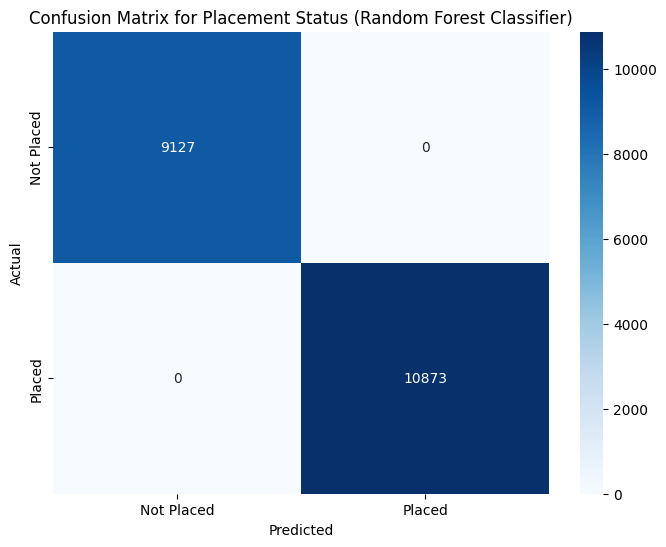

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Placement Status (Random Forest Classifier)')
plt.show()

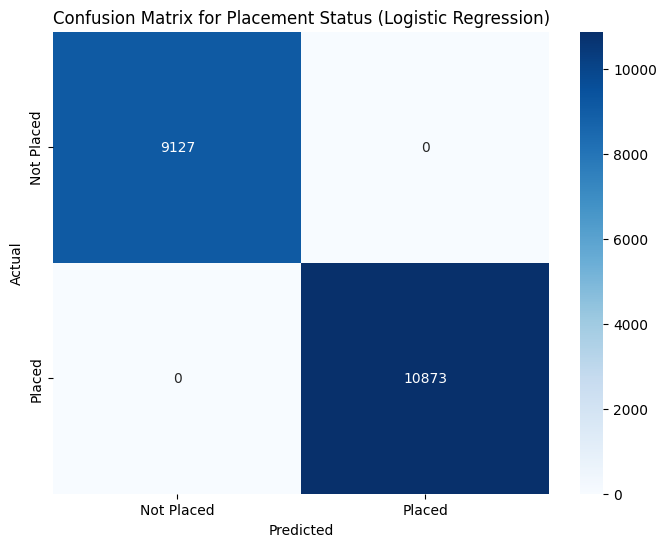

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y2_test, y2_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Placed', 'Placed'], yticklabels=['Not Placed', 'Placed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Placement Status (Logistic Regression)')
plt.show()